In [ ]:
# Build a regression model for the lipophilicity of molecules
# Upload the colab code and brief report discussing your procedure

I selected XGBoost as the regression model. XGBoost is a gradient boosting-based regression algorithm that improves performance by sequentially training multiple decision trees and correcting the errors of previous models. It can also effectively model nonlinear relationships and is well-suited for high-dimensional sparse molecular fingerprint data, which is why it was considered appropriate for lipophilicity prediction.

Molecular structures represented in SMILES format are converted into molecular structures using the RDKit library and then transformed into Morgan fingerprints. This fingerprint represents the substructure information of each molecule as a 2048-dimensional binary vector and is used as the input feature for the machine learning model. In the lecture, a 1024-dimensional representation was used, so I experimented with 2048 dimensions.

The model was trained using the training set and then used to predict lipophilicity values on the test set. The performance was evaluated using regression-appropriate metrics such as RMSE, MAE, and R². Finally, the predicted values were visualized to assess the model’s prediction performance and how well the distributions of true and predicted values match.

In [2]:
# First, RDKit is installed to set up the environment.

!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 34.3 MB/s eta 0:00:00


In [81]:
# Import the installed RDKit package and load the required libraries.

import rdkit
from rdkit.Chem import AllChem
from rdkit import Chem

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

To use XGBoost for the regression model, the XGBoost package is installed and imported, and pandas and numpy are also imported to load and inspect the data

In [17]:
pip install xgboost

In [21]:
import xgboost as xgb
import pandas as pd
import numpy as np
from xgboost import XGBRegressor     # A model for Regression
from matplotlib import pyplot as plt # A tool for data visualization (plotting graphs)

In [24]:
df_lip = pd.read_csv('Lipophilicity.csv')
df_lip = df_lip[['exp','smiles']]
df_lip

,exp,smiles
0,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...
...,...,...
4195,3.85,OCCc1ccc(NC(=O)c2cc3cc(Cl)ccc3[nH]2)cc1
4196,3.21,CCN(C1CCN(CCC(c2ccc(F)cc2)c3ccc(F)cc3)CC1)C(=O...
4197,2.10,COc1cccc2[nH]ncc12
4198,2.65,Clc1ccc2ncccc2c1C(=O)NCC3CCCCC3


In [27]:
# To verify that the data has been loaded correctly

print('df_lip.describe')
print(df_lip.describe())
print(df_lip.info())

df_lip.describe
               exp
count  4200.000000
mean      2.186336
std       1.203004
min      -1.500000
25%       1.410000
50%       2.360000
75%       3.100000
max       4.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   exp     4200 non-null   float64
 1   smiles  4200 non-null   object 
dtypes: float64(1), object(1)
memory usage: 65.8+ KB
None


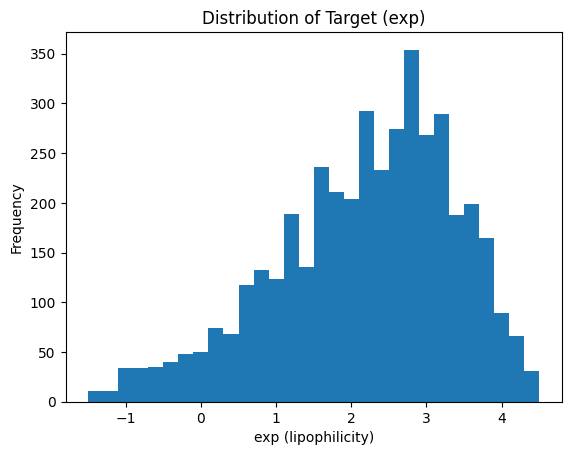

In [78]:
# To check whether the data is skewed or contains outliers, a histogram was used.

# In the lecture, positive/negative counts and unique values were examined; however, for continuous values, such checks are not very meaningful, so a histogram was used instead.

import matplotlib.pyplot as plt

plt.hist(df_lip['exp'], bins=30)
plt.xlabel("exp (lipophilicity)")
plt.ylabel("Frequency")
plt.title("Distribution of Target (exp)")
plt.show()

In [31]:
# Each column in the dataset is separated and stored as individual variables.

smiles = df_lip["smiles"]
exp = df_lip["exp"]
print(smiles)
print(exp)

0                 Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1       COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2                  COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3       OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4       Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...
                              ...                        
4195              OCCc1ccc(NC(=O)c2cc3cc(Cl)ccc3[nH]2)cc1
4196    CCN(C1CCN(CCC(c2ccc(F)cc2)c3ccc(F)cc3)CC1)C(=O...
4197                                   COc1cccc2[nH]ncc12
4198                      Clc1ccc2ncccc2c1C(=O)NCC3CCCCC3
4199                   CN1C(=O)C=C(CCc2ccc3ccccc3c2)N=C1N
Name: smiles, Length: 4200, dtype: object
0       3.54
1      -1.18
2       3.69
3       3.37
4       3.10
        ... 
4195    3.85
4196    3.21
4197    2.10
4198    2.65
4199    2.70
Name: exp, Length: 4200, dtype: float64


In [33]:
# Data preprocessing (converting SMILES into Morgan fingerprints to generate input features for machine learning models)

X = []
fpgen = AllChem.GetMorganGenerator(radius=3, fpSize=2048)      # Since this study focuses on lipophilicity, the radius was set to 3 to capture functional group-level substructures. The fingerprint size (fpSize) was set to 2048, which is commonly used for datasets of this scale (~4000 compounds), in order to capture more detailed structural information.
  mol = Chem.MolFromSmiles(i)
  fp = fpgen.GetFingerprint(mol)
  fp=np.array(fp)
  X.append(fp)

print(len(X))
print(len(X[0]))

4200
2048


In [34]:
X_Train, X_Test, y_Train, y_Test = train_test_split(X, exp, test_size= 0.2, random_state=42)

In [35]:
print('Type of X_Train: ', type(X_Train))
print('Type of X_Test: ', type(X_Test))
print('Type of y_Train: ', type(y_Train))
print('Type of y_Test: ', type(y_Test))

Type of X_Train:  <class 'list'>
Type of X_Test:  <class 'list'>
Type of y_Train:  <class 'pandas.core.series.Series'>
Type of y_Test:  <class 'pandas.core.series.Series'>


In [37]:
# To verify that the training data has been correctly constructed.

print('\nWHat is in X_Train?')
for i in range(3):
  print(X_Train[i])

print('\nWhat is in y_Train?')
print(y_Train.head(3))


WHat is in X_Train?
[0 1 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]

What is in y_Train?
2417    2.48
3827    1.70
239     3.27
Name: exp, dtype: float64


In [80]:
print(y_Train.describe())
print(y_Test.describe())

count    3360.000000
mean        2.197039
std         1.199616
min        -1.500000
25%         1.410000
50%         2.370000
75%         3.100000
max         4.500000
Name: exp, dtype: float64
count    840.000000
mean       2.143524
std        1.216238
min       -1.450000
25%        1.400000
50%        2.320000
75%        3.050000
max        4.490000
Name: exp, dtype: float64


In [48]:
# Hyperparameter tunning

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [50]:
model.fit(X_Train, y_Train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [52]:
y_pred = model.predict(X_Test)
print(y_pred[:3])

[2.4870183 1.7652606 0.5943293]


In [66]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_Test, y_pred))
r2 = r2_score(y_Test, y_pred)
mae = mean_absolute_error(y_Test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)
print("MAE:", mae)

RMSE: 0.7936628606782713
R2: 0.5736638827017765
MAE: 0.6052151983698076


Visualization

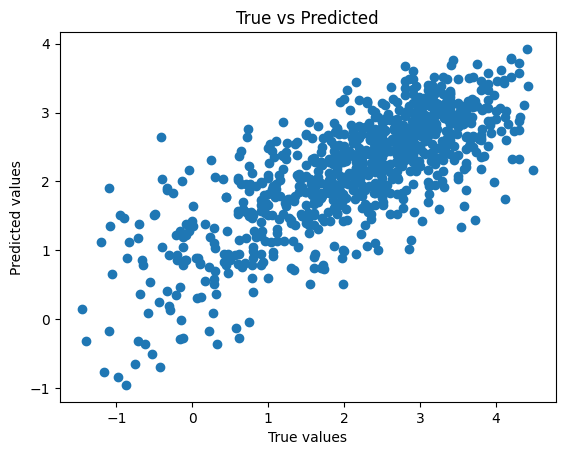

In [67]:
# A graph that visually compares the true values (y_Test) and predicted values (y_pred) to evaluate the model’s prediction accuracy.

import matplotlib.pyplot as plt

plt.scatter(y_Test, y_pred)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")
plt.show()

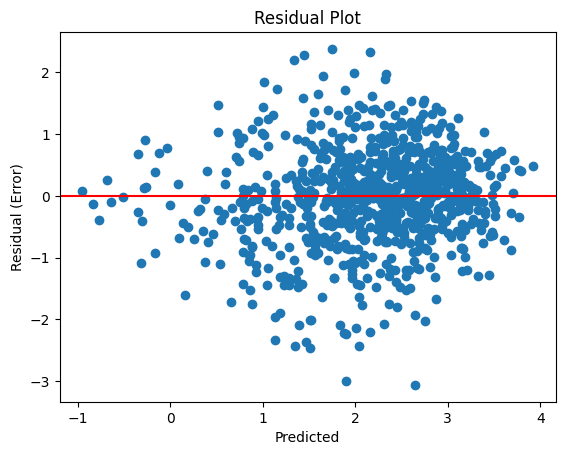

In [68]:
# A plot that shows the prediction errors (residuals) by plotting the difference between true and predicted values against the predicted values, used to evaluate error patterns in the model.

residuals = y_Test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot")
plt.show()

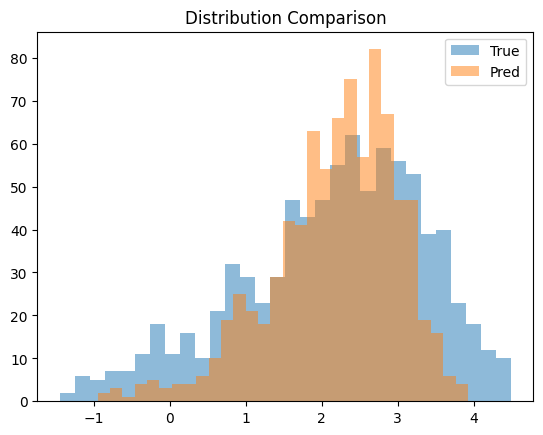

In [69]:
# A histogram that compares the distribution of true values (y_Test) and predicted values (y_pred) to evaluate how well the model captures the overall data distribution.

plt.hist(y_Test, bins=30, alpha=0.5, label='True')
plt.hist(y_pred, bins=30, alpha=0.5, label='Pred')
plt.legend()
plt.title("Distribution Comparison")
plt.show()

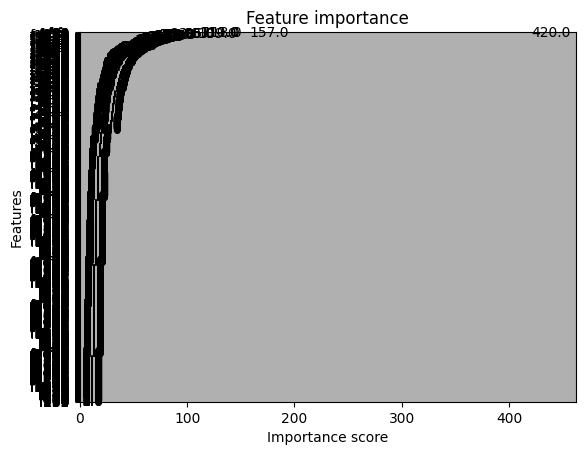

In [76]:
# Plotting Importance

xgb.plot_importance(model)
plt.show()